<a href="https://colab.research.google.com/github/Aaaaangla/3.CPI-Time-Series-Forecasting/blob/main/Report_for_forecasting_CPI_for_2020_to_2021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting Australian CPI Using Time Series Models

**Objective**

Develop and compre multiple forecasting models to predict Australia's Consumer Price Index (CPI) for 2020-20221 using historical quarterly data from 1990-2019.

**Project Goals**

*   List itemExplore long-term CPI behaviour
*   Assess stationarity and trend characteristics
*   Build statistical forecasting models
*   Compare forecasting performance
*   Generate future CPI predictions



# Project Summary

Dataset:

*   Quarterly CPI
*   1990 Q1 - 2019 Q4
*   120 observations

Model Evaluated:

* Linear Regression
* Polynomial Regresion
* ARIMA
* Exponential Smoothing

Evaaluation Metrics:

* RMSE
* MAE
* MAPE

Best Model:

* ARIMA(?, ?, ?)

Key Finding:

* CPI exhibits strong long-term upward trend.
* ARIMA outperformed baseline regression models





## Data Loading and demonstration

This section loads the Consumer Price Index (CPI) dataset and performs an initial exploratory analysis. The objective is to understand the structure, quality, and historical behaviour of the data before developing forecasting models.

The analysis includes:

* Dataset overview
* Data quality assessment
* Descriptive statistics
* Time series visualisation
* Trend investigation

Understanding these characteristics is essential for selecting appropriate forecasting techniques and evaluating model assumptions.

### Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import files
uploaded = files.upload()

Saving CPI_train.csv to CPI_train (1).csv


In [3]:
train = pd.read_csv('CPI_train.csv', index_col='Quarter', parse_dates=True)
train.index=train.index.to_period(freq='Q')
train=train['1990-03-01':]
y = train['CPI']
y.head()

,CPI
Quarter,
1990Q1,89.1
1990Q2,90.1
1990Q3,90.4
1990Q4,93.8
1991Q1,93.0


### Dataset Overview

The dataset contains quarterly Consumer Price Index (CPI) observations from 1990 Q1 to 2019 Q4.

Before modelling, it is important to verify that the dataset is complete and suitable for time series forecasting.

In [4]:
dataset_summary = pd.DataFrame({
    'Metric': [
        'Observations', 'Start Date', 'End Date', 'Frequency', 'Variables'
    ],
    'Value': [
        len(train), str(train.index.min()), str(train.index.max()), 'Quarterly', train.shape[1]
    ]
})

dataset_summary

,Metric,Value
0,Observations,120
1,Start Date,1990Q1
2,End Date,2019Q4
3,Frequency,Quarterly
4,Variables,1


### Data Quality Check

Missing values can significantly affect forecasting performance. Therefore, a data quality assessment is conducted before proceeding with further analysis.

In [5]:
print("Missing Values")
display(train.isnull().sum())

print("\nDataset Information")
train.info()

Missing Values


,0
CPI,0



Dataset Information
<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 120 entries, 1990Q1 to 2019Q4
Freq: Q-DEC
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CPI     120 non-null    float64
dtypes: float64(1)
memory usage: 1.9 KB


The dataset contains 120 quarterly observations with no missing values. The CPI variable is stored as a floating-point numerical variable and is therefore ready for statistical analysis and forecasting.

### Descriptive Statistics

Summary statistics provide an overview of the central tendency and variability of CPI throughout the observation period.

In [6]:
display(y.describe().round(4))

,CPI
count,120.0000
mean,112.4675
std,11.0543
min,89.1000
25%,102.8250
50%,116.4500
75%,121.3250
max,129.7000


The average CPI across the period is approximately 112.47 with a standard deviation of 11.05.

The minimum CPI recorded is 89.10, while the maximum value reaches 129.70.

The relatively narrow spread indicates a stable long-term growth pattern rather than extreme fluctuations.

### CPI Trend Analysis (Time Series Visualisation)

Visualising the CPI series allows us to identify long-term trends, structural changes, and potential seasonality.

A four-quarter moving average is also included to highlight the underlying trend and reduce short-term fluctuations.

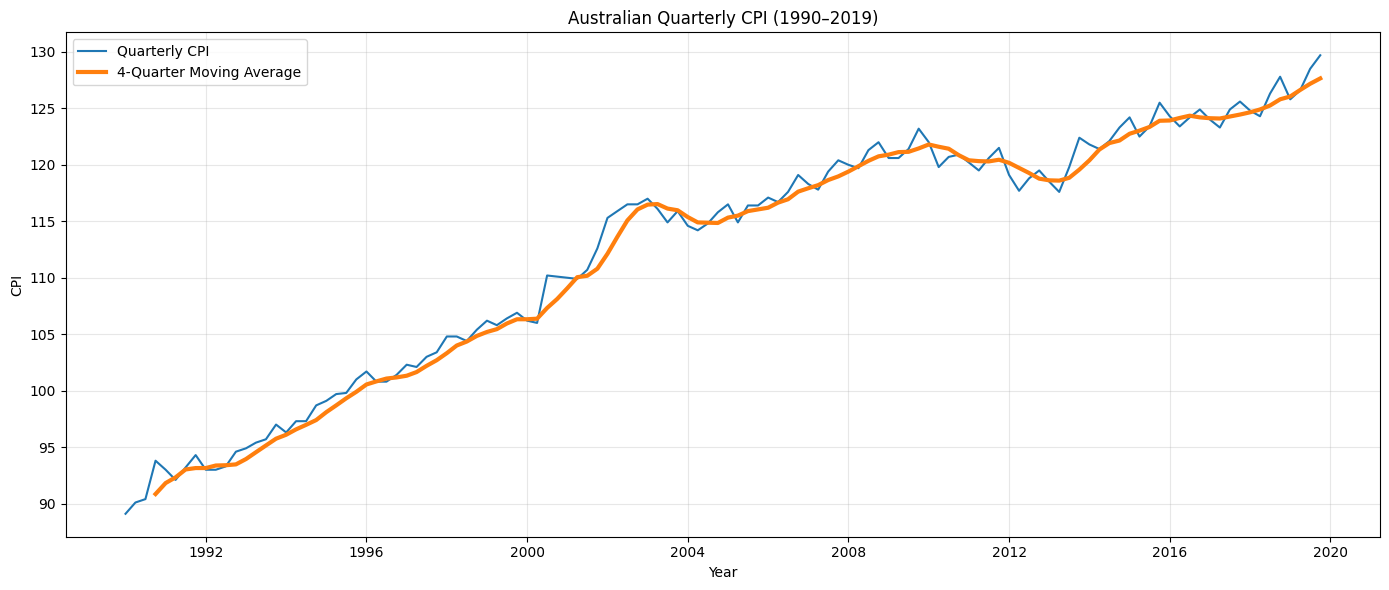

In [7]:
data = y.to_timestamp()
rolling_mean = data.rolling(window=4).mean()

plt.figure(figsize=(14,6))
plt.plot(data, label='Quarterly CPI')
plt.plot(rolling_mean, linewidth=3, label='4-Quarter Moving Average')
plt.title('Australian Quarterly CPI (1990–2019)')
plt.xlabel('Year')
plt.ylabel('CPI')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The CPI series demonstrates a clear upward trend over the thirty-year observation period.

Although short-term fluctuations are present, the overall movement remains consistently positive, suggesting persistent inflationary pressure within the Australian economy.

The moving average further confirms the existence of a strong long-term trend, indicating that the series is likely non-stationary and may require transformation before forecasting models such as ARIMA are applied.

### Preliminary Stationarity Assessment

Many time series forecasting techniques assume stationarity. Therefore, a preliminary assessment is conducted using the Augmented Dickey-Fuller (ADF) test.

In [8]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(data)

print("ADF Statistic :", round(adf_result[0],4))
print("p-value       :", round(adf_result[1],4))

ADF Statistic : -1.456
p-value       : 0.5551


A p-value greater than 0.05 indicates that the null hypothesis of a unit root cannot be rejected.

This suggests that the CPI series is non-stationary and exhibits a persistent trend over time.

Consequently, differencing or other transformations may be required before building forecasting models.

## Modelling

The objective of this study is to forecast quarterly CPI values for 2020–2021.

To evaluate different forecasting approaches, four models with varying levels of complexity are investigated:

- Linear Regression
- Polynomial Regression
- Simple Exponential Smoothing (SES)
- ARIMA

These models represent different forecasting philosophies, ranging from deterministic trend fitting to statistical time-series modelling.

Their forecasting performance will later be compared using prediction accuracy metrics.

### Model 1 – Linear Regression

Linear Regression is used as a baseline forecasting model.

The model assumes a linear relationship between time and CPI and provides a simple benchmark against which more advanced forecasting techniques can be evaluated.

In [9]:
time_index = np.arange(len(y))
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(time_index.reshape(-1,1), y)

lr_fitted = lr_model.predict(time_index.reshape(-1,1))

The fitted regression line captures the overall upward trend in CPI reasonably well.

However, the model cannot account for short-term fluctuations and assumes a constant growth rate throughout the entire observation period.

### Model 2 – Polynomial Regression

Polynomial Regression extends linear regression by introducing non-linear relationships between time and CPI.

This allows the model to capture curvature and acceleration in long-term inflation trends.

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(time_index.reshape(-1,1))
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
poly_fitted = poly_model.predict(X_poly)

Compared with the linear model, polynomial regression provides greater flexibility and is capable of modelling non-linear growth patterns observed in the CPI series.

### Model 3 – Simple Exponential Smoothing

Simple Exponential Smoothing (SES) forecasts future observations by assigning exponentially decreasing weights to older observations.

The method is particularly useful for smoothing random fluctuations and generating short-term forecasts.

Compared with regression-based models, SES places greater emphasis on recent observations and can adapt more effectively to local changes in the data.

In [11]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(y)
ses_fit = ses_model.fit()
ses_fitted = ses_fit.fittedvalues
display(ses_fit.params)

{'smoothing_level': np.float64(0.9999999850988388),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(89.1),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

The fitted values generated by the SES model are compared with the observed CPI series.

The Simple Exponential Smoothing model successfully reduces short-term fluctuations and produces a smoother representation of the CPI series.

However, the model does not explicitly account for long-term trends and therefore tends to lag behind the persistent upward movement observed in the CPI data.

Although SES provides a useful baseline forecasting approach, its ability to model sustained inflation growth is more limited than models specifically designed to capture trend behaviour.

### Model 4 – ARIMA

Autoregressive Integrated Moving Average (ARIMA) is one of the most widely used forecasting techniques for time series analysis.

Unlike regression-based approaches, ARIMA explicitly models temporal dependencies within the data and is capable of handling non-stationary time series through differencing.

As the CPI series exhibits a clear upward trend, stationarity must first be assessed before fitting an ARIMA model.

In [12]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(y)

print("ADF Statistic:", round(adf_result[0],4))
print("p-value:", round(adf_result[1],4))

ADF Statistic: -1.456
p-value: 0.5551


The ADF test produced a p-value greater than 0.05, indicating that the null hypothesis of a unit root cannot be rejected.

This suggests that the CPI series is non-stationary and contains a persistent trend.

Therefore, first-order differencing is applied before fitting the ARIMA model.

The differenced series produced a p-value below 0.05, indicating that stationarity has been achieved after first-order differencing.

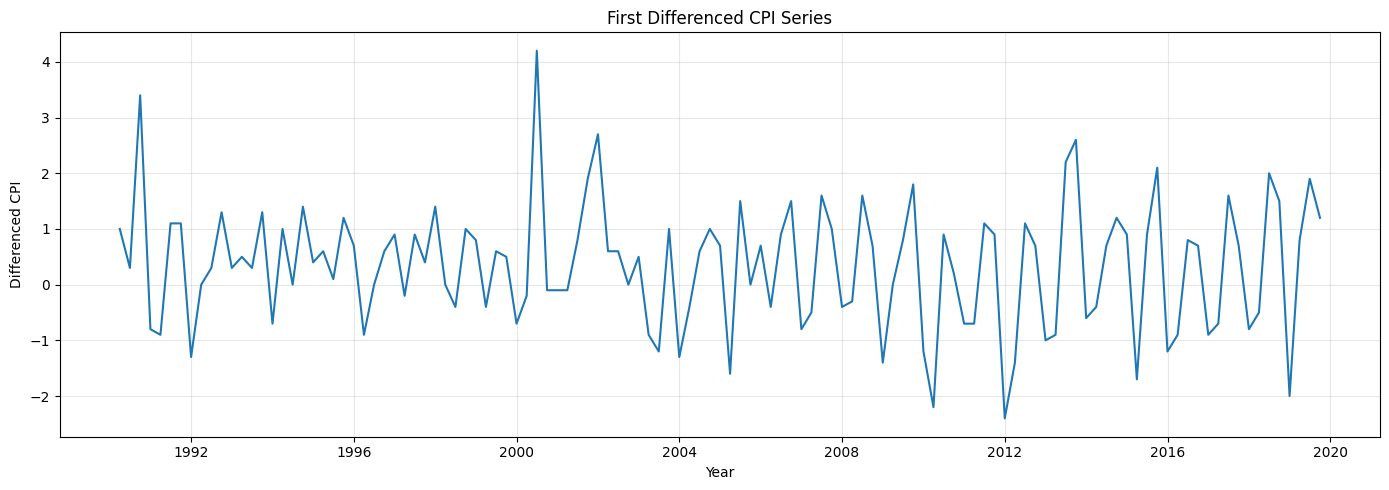

In [14]:
cpi_diff = y.diff().dropna()

plt.figure(figsize=(14,5))
plt.plot(cpi_diff.to_timestamp())
plt.title('First Differenced CPI Series')
plt.xlabel('Year')
plt.ylabel('Differenced CPI')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
adf_diff = adfuller(cpi_diff)

print("ADF Statistic:", round(adf_diff[0],4))
print("p-value:", round(adf_diff[1],4))

ADF Statistic: -4.3104
p-value: 0.0004


After differencing, the series fluctuates around a relatively stable mean and no longer exhibits a strong upward trend.

This suggests that the differenced series is more suitable for ARIMA modelling.

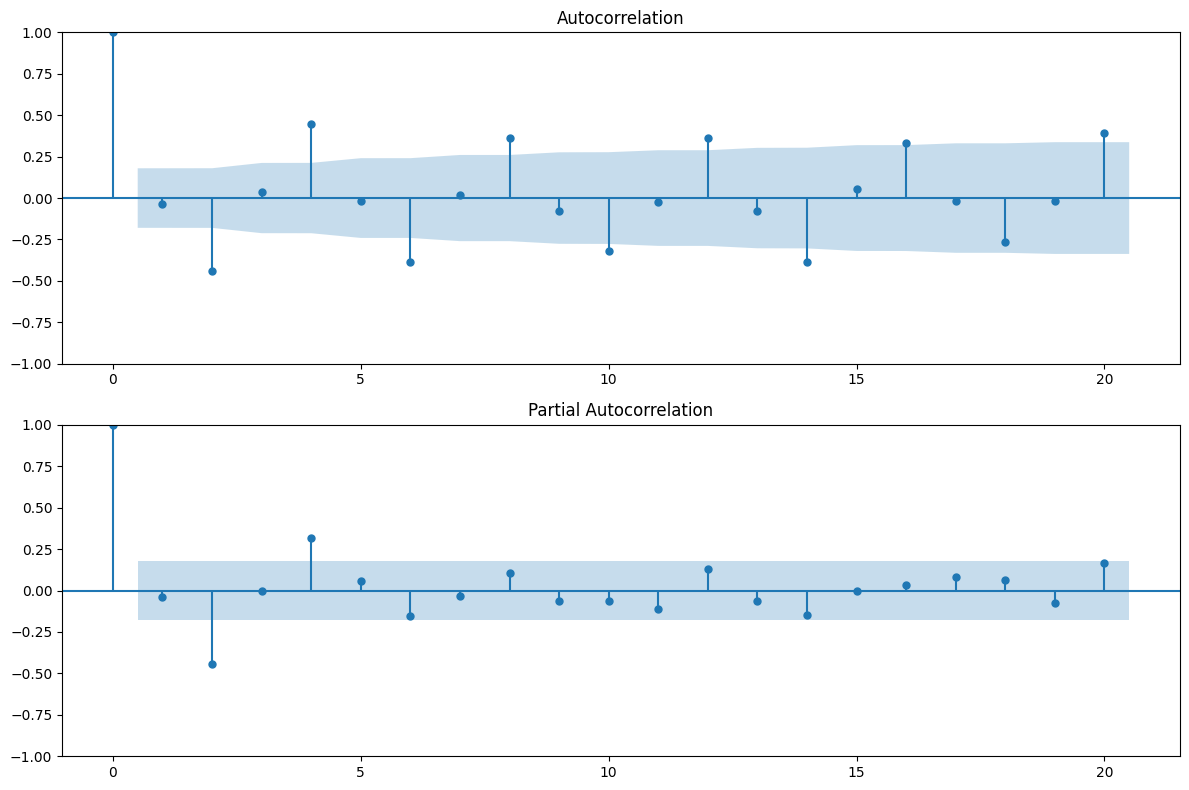

In [16]:
import statsmodels.api as sm

fig, ax = plt.subplots(2, 1, figsize=(12,8))
sm.graphics.tsa.plot_acf(cpi_diff, lags=20, ax=ax[0])
sm.graphics.tsa.plot_pacf(cpi_diff, lags=20, ax=ax[1])
plt.tight_layout()
plt.show()

The ACF and PACF plots indicate significant autocorrelation at lower lags.

Several candidate ARIMA specifications were considered.

An ARIMA(1,1,1) model was selected as an initial specification due to its ability to capture both autoregressive and moving-average dynamics.

In [17]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(y,order=(1,1,1))
arima_fit = arima_model.fit()

In [18]:
pd.DataFrame({
    'Parameter': arima_fit.params.index,
    'Value': arima_fit.params.values
})

,Parameter,Value
0,ar.L1,-0.420458
1,ma.L1,0.593249
2,sigma2,1.332040


The estimated AR coefficient is -0.42, indicating moderate negative dependence on the previous differenced observation.

The MA coefficient of 0.59 suggests that recent forecast errors contribute positively to future forecasts.

These results indicate that both autoregressive and moving-average effects are present within the differenced CPI series.

## Model Evaluation and selection



### Model Evaluation

#### Model 1 - Linear Regression Actual vs Fitted

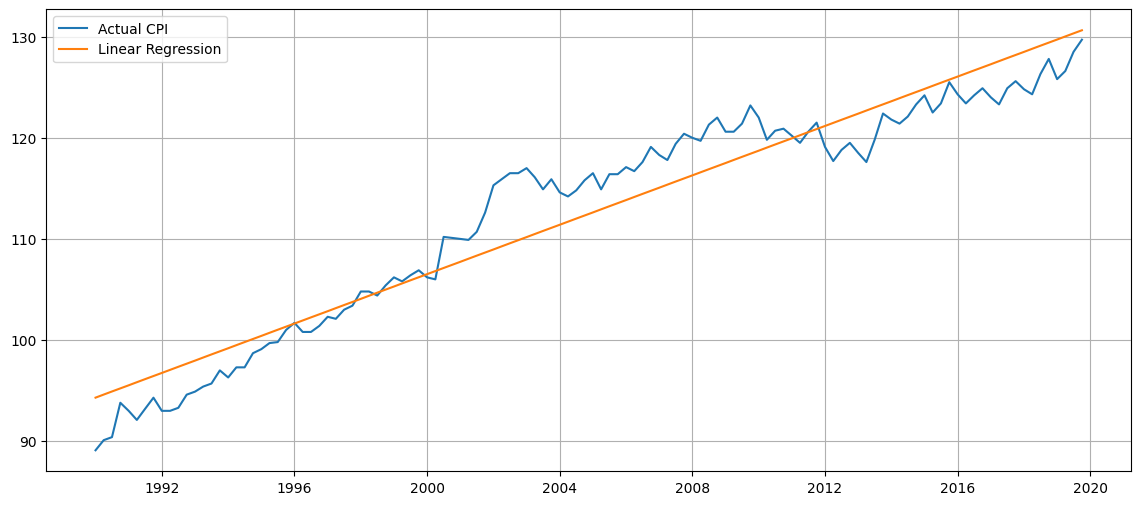

In [19]:
plt.figure(figsize=(14,6))

plt.plot(data,label='Actual CPI')
plt.plot(data.index,lr_fitted,
         label='Linear Regression')

plt.legend()
plt.grid(True)
plt.show()

#### Model 1 - Linear Regression Residual Plot

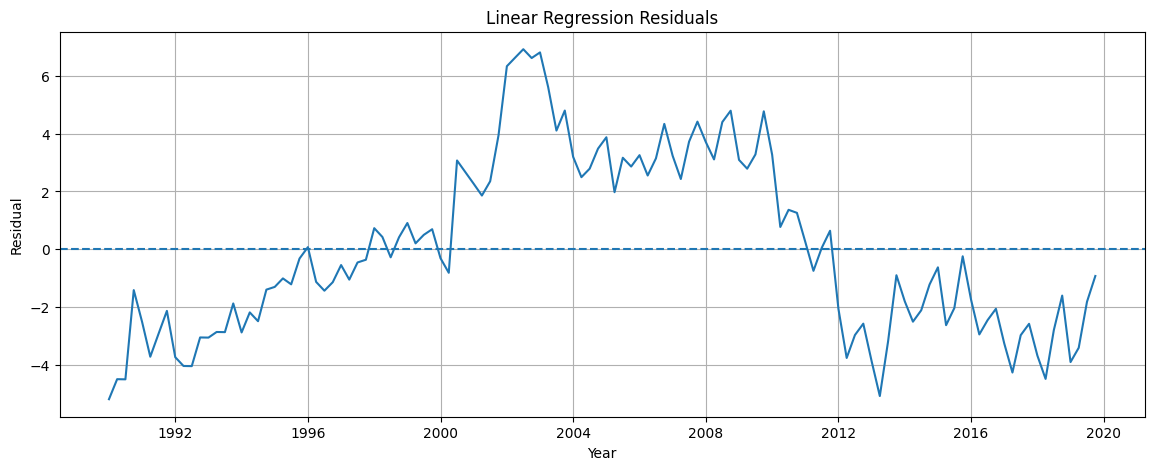

In [20]:
lr_residual = y - lr_fitted

plt.figure(figsize=(14,5))
plt.plot(lr_residual.index.to_timestamp(), lr_residual.values)
plt.axhline(y=0, linestyle='--')
plt.title('Linear Regression Residuals')
plt.xlabel('Year')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

#### Model 1 - Linear regression RMSE, MAE, MAPE

In [21]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y, lr_fitted))
mae_lr = mean_absolute_error(y, lr_fitted)
mape_lr = np.mean(np.abs((y - lr_fitted) / y)) * 100

print(f"RMSE : {rmse_lr:.4f}")
print(f"MAE  : {mae_lr:.4f}")
print(f"MAPE : {mape_lr:.2f}%")

RMSE : 3.0592
MAE  : 2.6093
MAPE : 2.33%


#### Model 2 - Polynomial Regression Actual vs Fitted

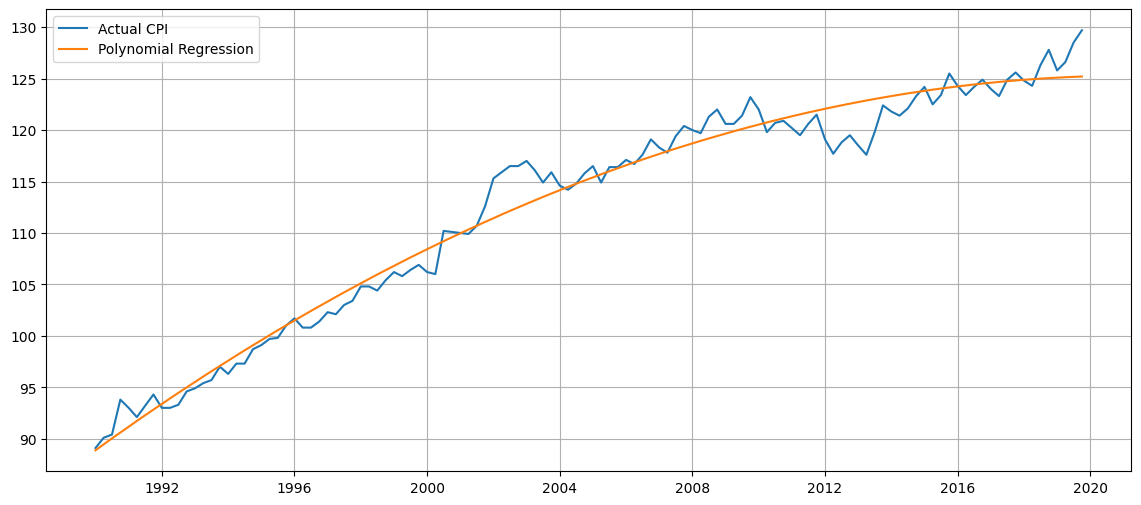

In [22]:
plt.figure(figsize=(14,6))
plt.plot(data,label='Actual CPI')
plt.plot(data.index,poly_fitted, label='Polynomial Regression')
plt.legend()
plt.grid(True)
plt.show()

#### Model 2 - Polynomial Regression Residual Plot

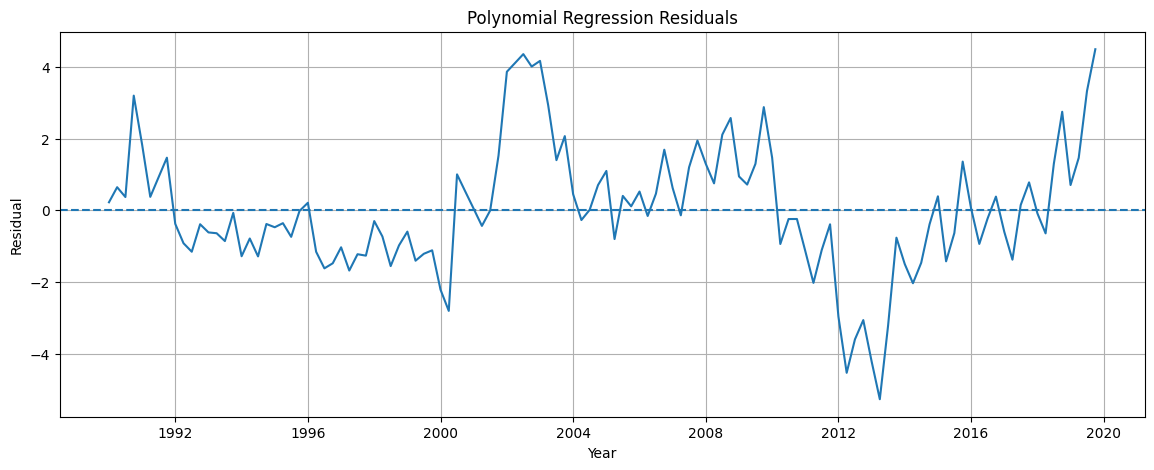

In [23]:
poly_residual = y - poly_fitted

plt.figure(figsize=(14,5))
plt.plot(poly_residual.index.to_timestamp(), poly_residual.values)
plt.axhline(y=0, linestyle='--')
plt.title('Polynomial Regression Residuals')
plt.xlabel('Year')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

#### Model 2 - Polynomial regression RMSE, MAE, MAPE

In [24]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

rmse_poly = np.sqrt(mean_squared_error(y, poly_fitted))
mae_poly = mean_absolute_error(y, poly_fitted)
mape_poly = np.mean(np.abs((y - poly_fitted) / y)) * 100

print(f"RMSE : {rmse_poly:.4f}")
print(f"MAE  : {mae_poly:.4f}")
print(f"MAPE : {mape_poly:.2f}%")

RMSE : 1.7794
MAE  : 1.3278
MAPE : 1.17%


#### Model 3 - SES Actual vs fitted

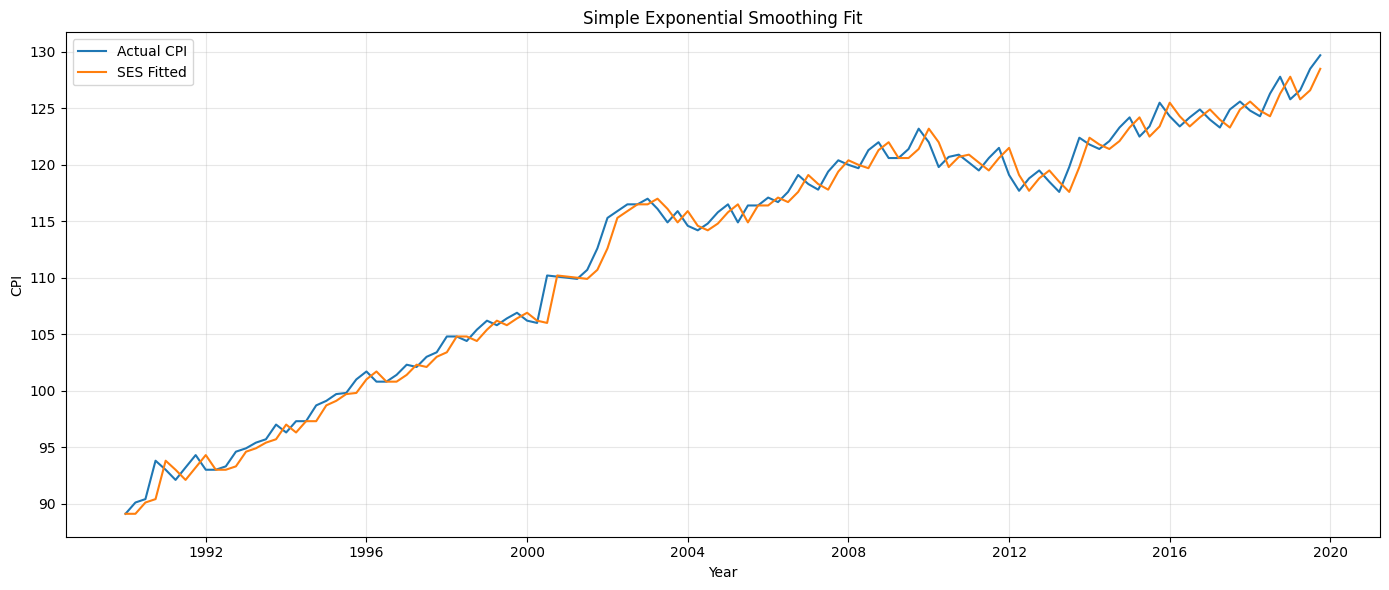

In [25]:
plt.figure(figsize=(14,6))
plt.plot(data, label='Actual CPI')
plt.plot(data.index, ses_fitted, label='SES Fitted')
plt.title('Simple Exponential Smoothing Fit')
plt.xlabel('Year')
plt.ylabel('CPI')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Model 3 - SES Residual Plot

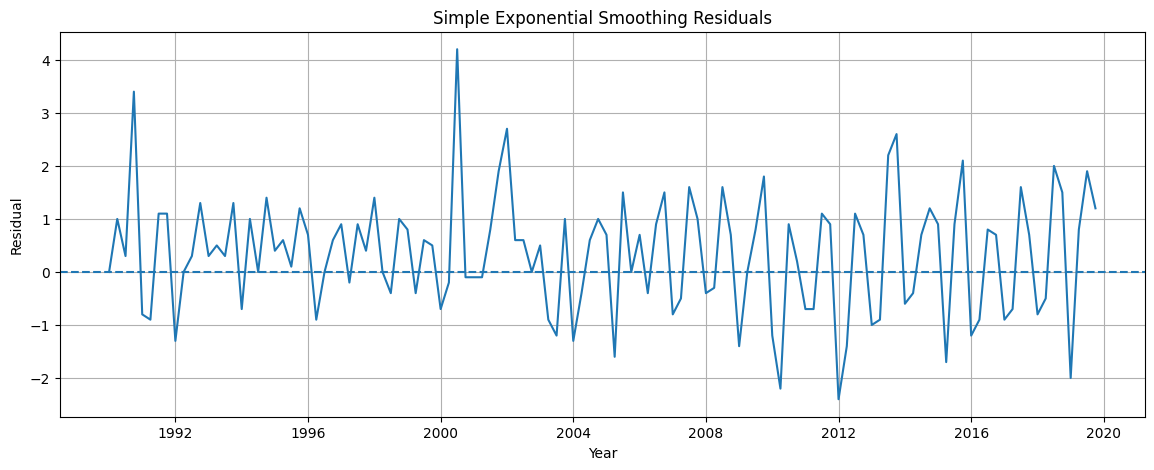

In [26]:
ses_residual = y - ses_fitted

plt.figure(figsize=(14,5))
plt.plot(ses_residual.index.to_timestamp(), ses_residual.values)
plt.axhline(y=0, linestyle='--')
plt.title('Simple Exponential Smoothing Residuals')
plt.xlabel('Year')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

#### Model 3 - SES RMSE, MAE, MAPE

In [27]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

rmse_ses = np.sqrt(mean_squared_error(y, ses_fitted))
mae_ses = mean_absolute_error(y, ses_fitted)
mape_ses = np.mean(np.abs((y - ses_fitted) / y)) * 100

print(f"RMSE : {rmse_ses:.4f}")
print(f"MAE  : {mae_ses:.4f}")
print(f"MAPE : {mape_ses:.2f}%")

RMSE : 1.1698
MAE  : 0.9417
MAPE : 0.83%


#### Model 4 - ARIMA actual vs fitted

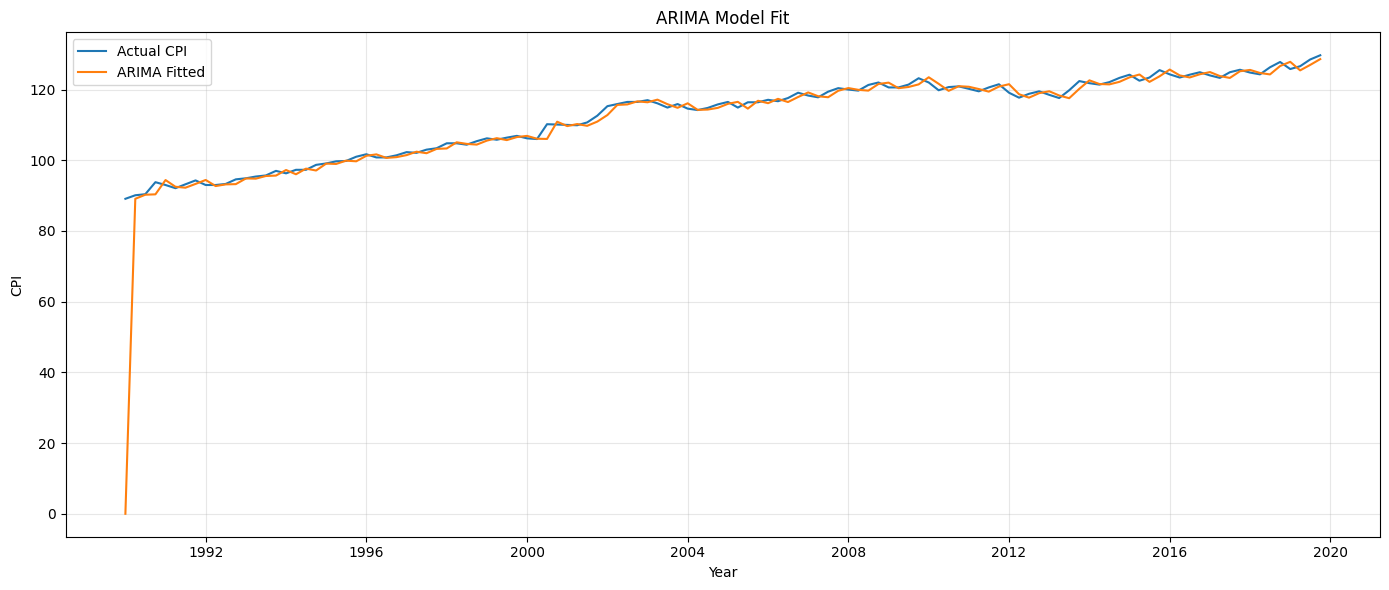

In [28]:
arima_fitted = arima_fit.predict()

plt.figure(figsize=(14,6))
plt.plot(data, label='Actual CPI')
plt.plot(data.index, arima_fitted, label='ARIMA Fitted')
plt.title('ARIMA Model Fit')
plt.xlabel('Year')
plt.ylabel('CPI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Model 4 - ARIMA Residual Plot

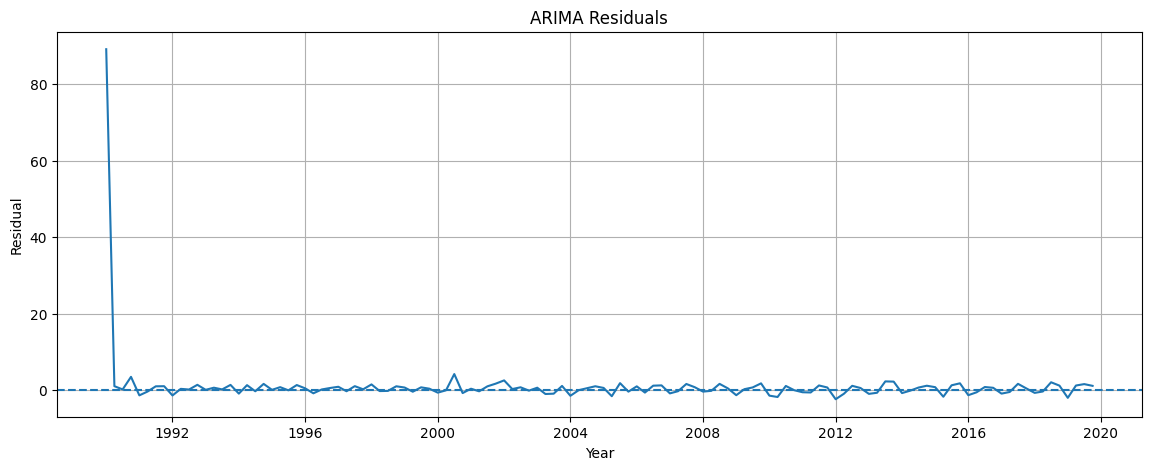

In [29]:
arima_residual = y - arima_fitted

plt.figure(figsize=(14,5))
plt.plot(arima_residual.index.to_timestamp(), arima_residual.values)
plt.axhline(y=0, linestyle='--')
plt.title('ARIMA Residuals')
plt.xlabel('Year')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

#### Model 4 - ARIMA RMSE, MAE, MAPE

In [30]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

rmse_arima = np.sqrt(mean_squared_error(y.iloc[1:], arima_fitted.iloc[1:]))
mae_arima = mean_absolute_error(y.iloc[1:], arima_fitted.iloc[1:])
mape_arima = np.mean(np.abs((y.iloc[1:] - arima_fitted.iloc[1:])/y.iloc[1:])) * 100

print(f"RMSE : {rmse_arima:.4f}")
print(f"MAE  : {mae_arima:.4f}")
print(f"MAPE : {mape_arima:.2f}%")

RMSE : 1.1545
MAE  : 0.9333
MAPE : 0.83%


### Model selection

In [31]:
comparison = pd.DataFrame({
    'Model':['Linear Regression', 'Polynomial Regression', 'SES', 'ARIMA'],
    'RMSE':[rmse_lr, rmse_poly, rmse_ses, rmse_arima],
    'MAE':[mae_lr, mae_poly, mae_ses, mae_arima],
    'MAPE (%)':[mape_lr, mape_poly, mape_ses, mape_arima]
})

comparison.sort_values('RMSE')

,Model,RMSE,MAE,MAPE (%)
3,ARIMA,1.154471,0.933272,0.826866
2,SES,1.169758,0.941667,0.831643
1,Polynomial Regression,1.779422,1.327834,1.168182
0,Linear Regression,3.059186,2.609322,2.328503


ARIMA delivered the best forecasting performance, achieving the lowest RMSE, MAE, and MAPE values. The small performance gap between ARIMA and SES suggests that CPI is a highly persistent and stable time series, making it relatively predictable over short forecasting horizons. Overall, ARIMA was selected as the preferred forecasting model.

## Model development ##

In this section, the weakness of the original model will be identified and improved. The new developed model will be provided in the end of this section.

### Step 1. Residual Dignostics

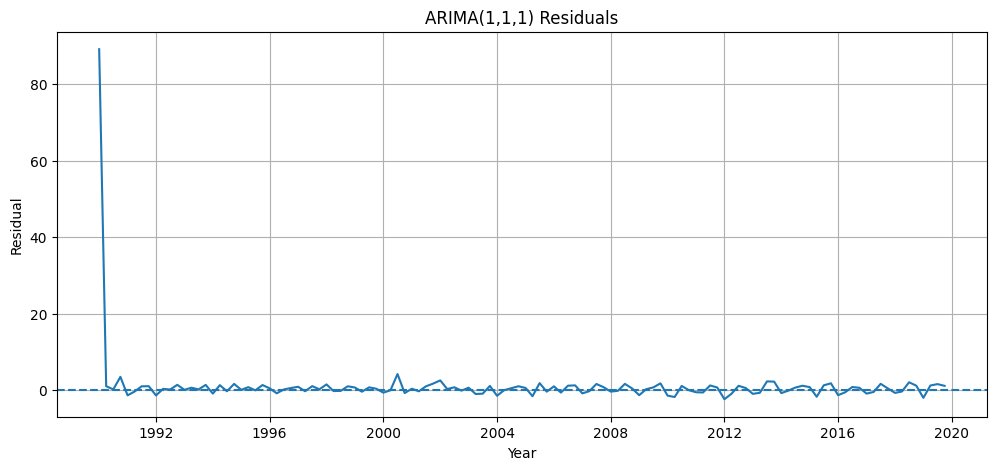

In [32]:
# Residual Diagnostics

residuals = arima_fit.resid

plt.figure(figsize=(12,5))
plt.plot(residuals.index.to_timestamp(), residuals)
plt.axhline(y=0, linestyle='--')
plt.title('ARIMA(1,1,1) Residuals')
plt.xlabel('Year')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

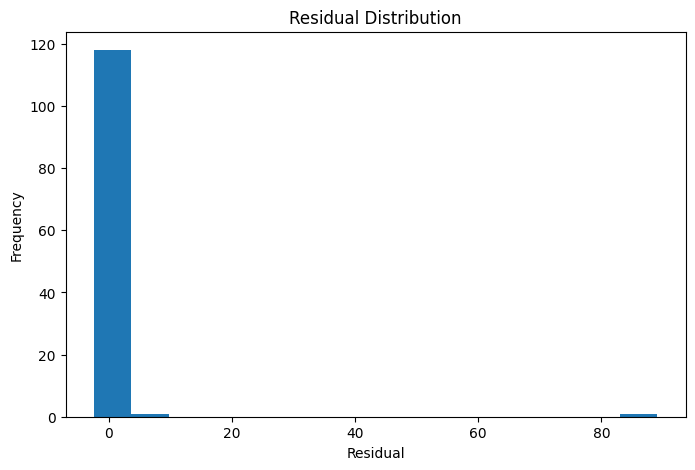

In [33]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=15)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')

plt.show()

### Step 2. Candidate ARIMA Models

In [34]:
!pip install pmdarima

In [35]:
from pmdarima import auto_arima

auto_model = auto_arima(
    y,

    start_p=0,
    start_q=0,

    max_p=5,
    max_q=5,

    max_d=2,

    seasonal=False,

    stepwise=False,

    trace=True,

    error_action='ignore',

    suppress_warnings=True,

    n_jobs=-1

)

print(auto_model.summary())


Best model:  ARIMA(2,1,2)(0,0,0)[0] intercept
Total fit time: 9.643 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  120
Model:               SARIMAX(2, 1, 2)   Log Likelihood                -155.278
Date:                Tue, 09 Jun 2026   AIC                            322.556
Time:                        01:45:41   BIC                            339.231
Sample:                    03-31-1990   HQIC                           329.328
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6725      0.173      3.876      0.000       0.332       1.012
ar.L1         -0.0144      0.025     -0.579      0.563

### Step 3. Fit Optimised Model

In [39]:
best_order = auto_model.order

(2, 1, 2)


The optimised model is: ARIMA(2,1,2)

In [40]:
optimised_model = ARIMA(y, order=best_order)
optimised_fit = optimised_model.fit()

### Step 4. Compare Original vs Optimised

In [41]:
original_pred = arima_fit.predict()
optimised_pred = optimised_fit.predict()

In [42]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

rmse_original = np.sqrt(mean_squared_error(y.iloc[1:], original_pred.iloc[1:]))
rmse_optimised = np.sqrt(mean_squared_error(y.iloc[1:], optimised_pred.iloc[1:]))
mae_original = mean_absolute_error(y.iloc[1:], original_pred.iloc[1:])
mae_optimised = mean_absolute_error(y.iloc[1:], optimised_pred.iloc[1:])
mape_original = np.mean(np.abs((y.iloc[1:]-original_pred.iloc[1:])/y.iloc[1:])) * 100
mape_optimised = np.mean(np.abs((y.iloc[1:]-optimised_pred.iloc[1:])/y.iloc[1:])) * 100

In [43]:
comparison_dev = pd.DataFrame({
    'Model':['ARIMA(1,1,1)', 'Optimised ARIMA'],
    'RMSE':[rmse_original, rmse_optimised],
    'MAE':[mae_original, mae_optimised],
    'MAPE (%)':[mape_original, mape_optimised]
})

comparison_dev

,Model,RMSE,MAE,MAPE (%)
0,"ARIMA(1,1,1)",1.154471,0.933272,0.826866
1,Optimised ARIMA,0.970358,0.702655,0.634882


### Final Model

The optimal forecasting model selected using Auto ARIMA was ARIMA(2,1,2), with an AIC of 322.56.

The model incorporates first-order differencing to remove non-stationarity, together with two autoregressive terms and two moving-average terms to capture temporal dependencies in the CPI series.

## Prediction

This section provided the forecast quarterly CPI from 2020Q1 to 2021Q4, a total of eight values.

In [44]:
forecast = optimised_fit.forecast(steps=8)
future_periods = pd.period_range(start='2020Q1', periods=8, freq='Q')
forecast_table = pd.DataFrame({'Quarter':future_periods, 'Forecast CPI':forecast.values})
forecast_table

,Quarter,Forecast CPI
0,2020Q1,128.491442
1,2020Q2,127.809201
2,2020Q3,129.020193
3,2020Q4,129.680969
4,2021Q1,128.467865
5,2021Q2,127.828454
6,2021Q3,129.043352
7,2021Q4,129.661501


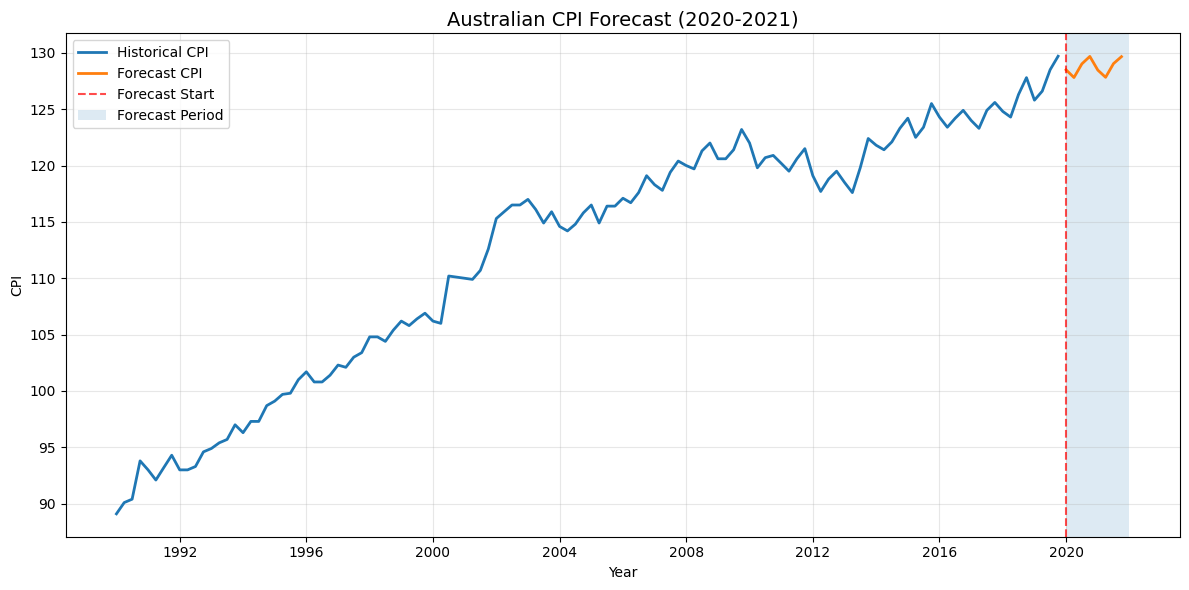

In [45]:
# Plot

plt.figure(figsize=(12,6))

# Historical CPI
plt.plot(y.index.to_timestamp(), y, label='Historical CPI', linewidth=2)

# Forecast CPI
plt.plot(future_periods.to_timestamp(), forecast, label='Forecast CPI',linewidth=2)

# Forecast starting point
plt.axvline(x=pd.Timestamp('2020-01-01'), color='red', linestyle='--', alpha=0.7, label='Forecast Start')

# Forecast period shading
plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.15, label='Forecast Period')
plt.title('Australian CPI Forecast (2020-2021)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('CPI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

This report presents a comprehensive analysis of the quarterly CPI data from 1990 to 2019 and aims to develop a predictive model for forecasting quarterly CPI values in 2020 and 2021. Simple exponential smoothing method and Autoregressive Integrated Moving Average model has been selected to be compared in the begining based on the explortary anaysis applied previously. Despite SES offers a smaller MSE with more accurate preditive ability, ARIMA is better suited for this time series data with a overall better goodness of model fit and model complexity. By evaluating the minimum AIC, the most suitable ARIMA model has been developed, which is the ARMA(2,2). This model effective incorporates both autoregressive and mocing average components and provides a robust framework for forecasting CPI values with high accuracy. Lastly, the forecasted CPI values for 2020Q1 to 2021Q4 indicates a gradual increasing trend.